# 06 - Stress test: does the model hold up on home-style photos?

The **validation** split is re-rendered under fixed conditions that mimic how Noor's leaf gets photographed at home (`src/stress.py`). Every model sees exactly the same images. This notebook is for **choosing a model**, so it uses validation, not test; the test split stays untouched for the final evaluation.

- **Seen** conditions come from the same families the scenario augmentation trains on, so they favour the scenario models by construction.
- **UNSEEN** conditions (cool LED light, a heavily compressed forwarded photo, stronger motion blur) are outside every model's training augmentation: the fairer comparison.
- All conditions are **synthetic**. This measures robustness to simulated home conditions, not accuracy on real home photos.

Metrics per model and condition: accuracy, macro-F1, mean top probability, and **confident-wrong rate**: the share of images where the model is wrong while giving its answer at least 80% probability. That last one is the dangerous case for Noor. Probabilities are not calibrated yet, so treat it as a relative comparison.

In [1]:
import sys
from pathlib import Path

ML = Path.cwd()
while not (ML / "src").exists():
    ML = ML.parent
sys.path.insert(0, str(ML))

import time

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import f1_score
from torch.utils.data import DataLoader

from src.config import CLASSES, CROPS, MASKS, SPLITS
from src.model import load_checkpoint
from src.stress import CONDITIONS, AllConditionsDataset, render
from src.train import CHECKPOINTS, get_device

ARTIFACTS = ML / "artifacts"
ARTIFACTS.mkdir(exist_ok=True)
device = get_device()
RUN_NAMES = ["light_v1", "scenario_v1", "scenario_320"]
CONFIDENT = 0.8

## What the conditions look like

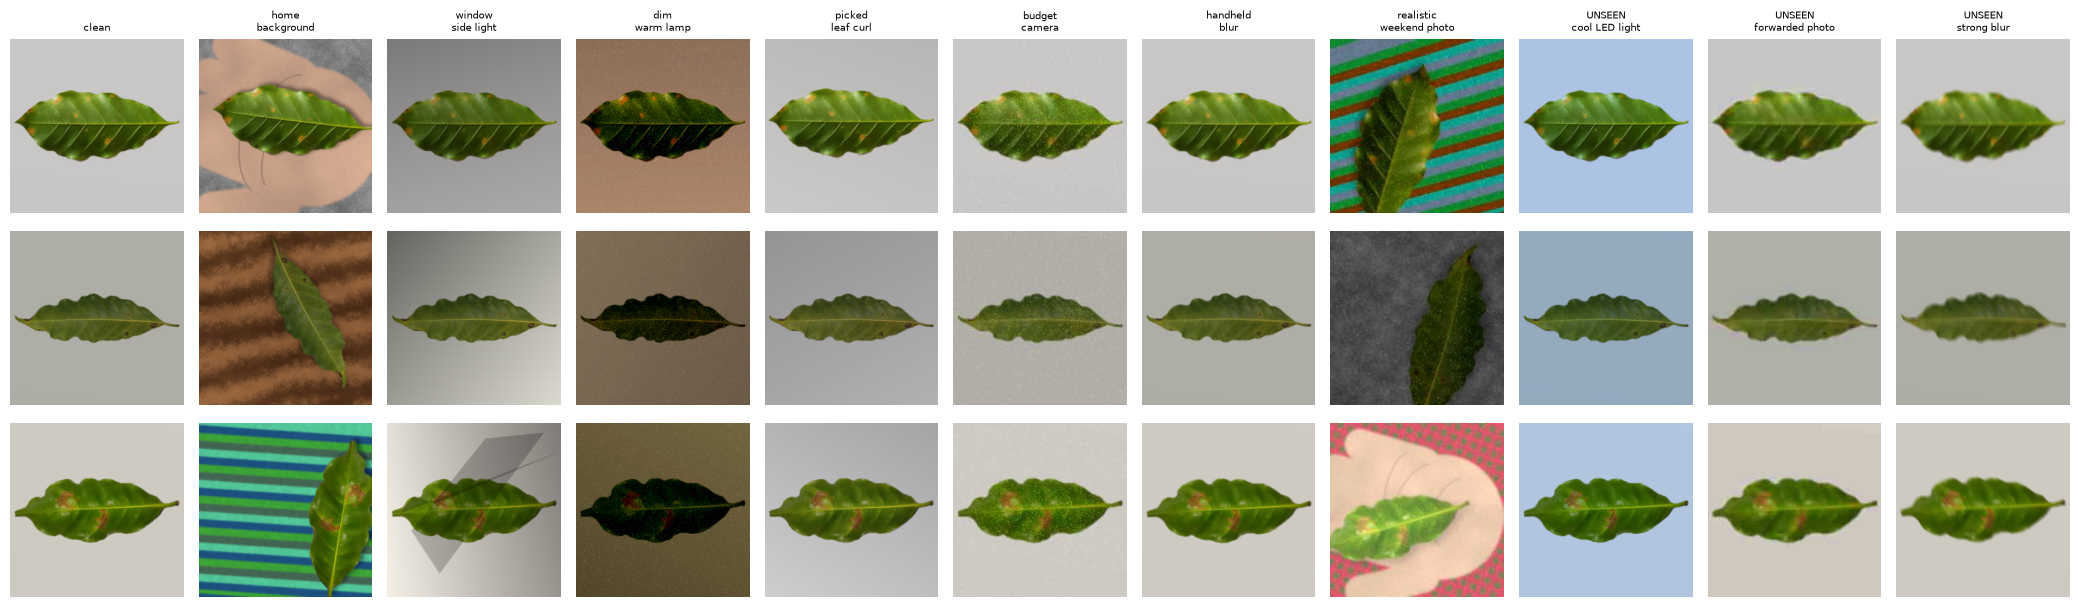

In [2]:
examples = [1348, 1582, 225]  # rust, cercospora, leaf miner
fig, axes = plt.subplots(len(examples), len(CONDITIONS), figsize=(1.9 * len(CONDITIONS), 2.1 * len(examples)))
for r, image_id in enumerate(examples):
    crop = cv2.cvtColor(cv2.imread(str(CROPS / f"{image_id}.jpg")), cv2.COLOR_BGR2RGB)
    mask = cv2.imread(str(MASKS / f"{image_id}.png"), cv2.IMREAD_GRAYSCALE)
    for c, cond in enumerate(CONDITIONS):
        axes[r, c].imshow(render(cond, crop, mask, image_id, 256))
        axes[r, c].axis("off")
        if r == 0:
            axes[r, c].set_title(cond.replace(" ", "\n", 1), fontsize=7)
plt.tight_layout()

## Run every model on every condition

Each input size is rendered once through a single DataLoader, and every model with that size scores the same batches. This avoids restarting worker processes for each model/condition pair.

In [3]:
models = {}
for run in RUN_NAMES:
    model, ckpt = load_checkpoint(CHECKPOINTS / f"{run}_best.pt", device)
    models[run] = (model, ckpt["config"]["size"])

outputs = {run: {"logits": [], "labels": [], "cond": []} for run in RUN_NAMES}
t0 = time.time()
for size in sorted({s for _, s in models.values()}):
    runs = [r for r, (_, s) in models.items() if s == size]
    dl = DataLoader(AllConditionsDataset(SPLITS / "val.csv", size), batch_size=64, num_workers=6)
    with torch.no_grad():
        for x, y, k in dl:
            x = x.to(device)
            for run in runs:
                outputs[run]["logits"].append(models[run][0](x).float().cpu())
                outputs[run]["labels"].append(y)
                outputs[run]["cond"].append(k)
    print(f"size {size}: {runs} done ({time.time() - t0:.0f}s)")

rows = []
names = list(CONDITIONS)
for run in RUN_NAMES:
    logits, labels, cond = (torch.cat(outputs[run][key]) for key in ("logits", "labels", "cond"))
    probs = torch.softmax(logits, 1)
    conf, preds = probs.max(1)
    for k, name in enumerate(names):
        sel = cond == k
        wrong = preds[sel] != labels[sel]
        rows.append({
            "run": run, "condition": name, "seen": CONDITIONS[name][0],
            "acc": 1 - wrong.float().mean().item(),
            "macro_f1": f1_score(labels[sel], preds[sel], average="macro"),
            "mean_top_prob": conf[sel].mean().item(),
            "confident_wrong": (wrong & (conf[sel] >= CONFIDENT)).float().mean().item(),
        })

results = pd.DataFrame(rows)
results.to_csv(ARTIFACTS / "stress_test_val.csv", index=False)


size 256: ['light_v1', 'scenario_v1'] done (57s)


size 320: ['scenario_320'] done (115s)


## Macro-F1 per condition

In [4]:
order = list(CONDITIONS)
f1 = results.pivot(index="condition", columns="run", values="macro_f1").loc[order, RUN_NAMES]
seen = pd.Series({c: s for c, (s, _) in CONDITIONS.items()})
f1.loc["MEAN seen (excl. clean)"] = f1.loc[[c for c in order if seen[c] and c != "clean"]].mean()
f1.loc["MEAN unseen"] = f1.loc[[c for c in order if not seen[c]]].mean()
f1.round(3).style.background_gradient(cmap="Greens", vmin=0.3, vmax=1.0, axis=None).format("{:.3f}")

run,light_v1,scenario_v1,scenario_320
condition,,,
clean,0.901,0.870,0.885
home background,0.466,0.792,0.791
window side light,0.792,0.864,0.833
dim warm lamp,0.325,0.627,0.553
picked leaf curl,0.910,0.819,0.844
budget camera,0.818,0.855,0.850
handheld blur,0.909,0.856,0.865
realistic weekend photo,0.288,0.689,0.663
UNSEEN cool LED light,0.550,0.814,0.827


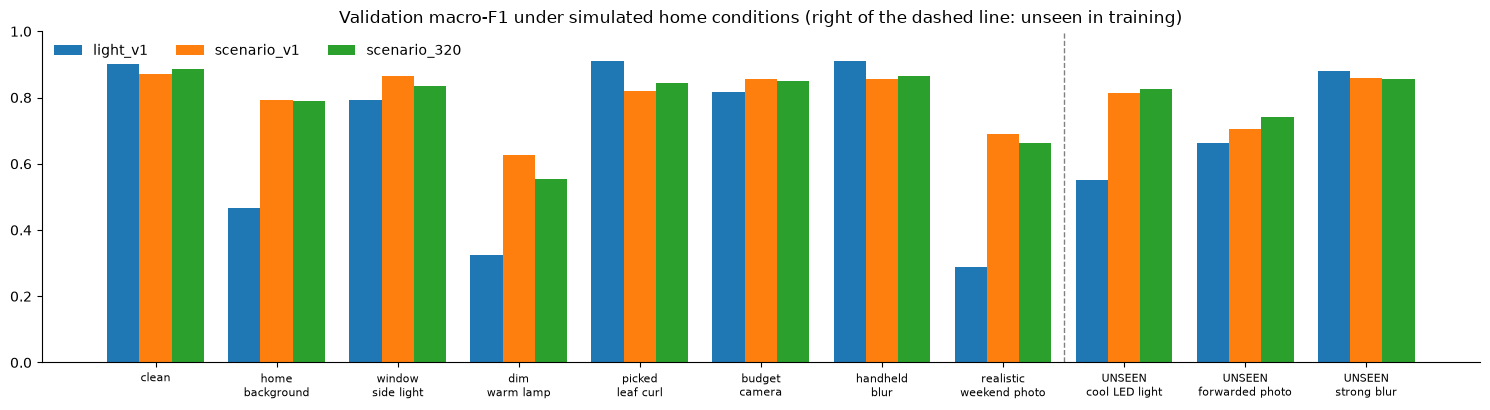

In [5]:
def grouped_bars(metric, title, ylim, fname):
    table = results.pivot(index="condition", columns="run", values=metric).loc[order, RUN_NAMES]
    x = np.arange(len(order))
    w = 0.8 / len(RUN_NAMES)
    fig, ax = plt.subplots(figsize=(15, 4.2))
    for k, run in enumerate(RUN_NAMES):
        ax.bar(x + (k - (len(RUN_NAMES) - 1) / 2) * w, table[run], width=w, label=run)
    ax.axvline(sum(seen[order]) - 0.5, color="grey", ls="--", lw=1)
    ax.set_xticks(x, [c.replace(" ", "\n", 1) for c in order], fontsize=8)
    ax.set_ylim(*ylim)
    ax.set_title(title)
    ax.legend(frameon=False, ncol=len(RUN_NAMES))
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    fig.savefig(ARTIFACTS / fname, dpi=120, bbox_inches="tight")

grouped_bars("macro_f1", "Validation macro-F1 under simulated home conditions (right of the dashed line: unseen in training)",
             (0, 1), "stress_test_val_f1.png")

## Confident wrong answers (the dangerous case)

run,light_v1,scenario_v1,scenario_320
condition,,,
clean,0.055,0.040,0.030
home background,0.249,0.050,0.045
window side light,0.085,0.035,0.035
dim warm lamp,0.478,0.124,0.139
picked leaf curl,0.045,0.040,0.035
budget camera,0.060,0.040,0.050
handheld blur,0.055,0.030,0.025
realistic weekend photo,0.428,0.060,0.109
UNSEEN cool LED light,0.184,0.065,0.055


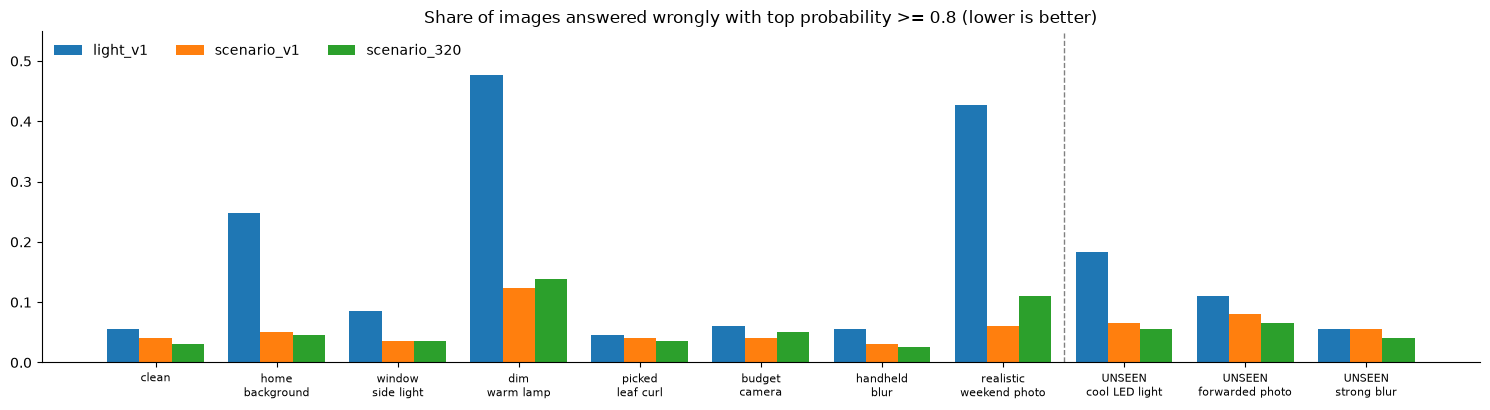

In [6]:
grouped_bars("confident_wrong", f"Share of images answered wrongly with top probability >= {CONFIDENT} (lower is better)",
             (0, max(0.05, results["confident_wrong"].max() * 1.15)), "stress_test_val_confident_wrong.png")

cw = results.pivot(index="condition", columns="run", values="confident_wrong").loc[order, RUN_NAMES]
cw.loc["MEAN all conditions"] = cw.mean()
cw.round(3)